# Cross-Task GRU: Generalization and Hidden Dynamics

IICCSSS 2026 hackathon · Azulejos dataset · Traditional vs recurrent behavioral modeling

**Goal**: train one **shared GRU** on many task designs (different visibility, n_actions, n_states, points/probs types...), then:

1. Run replay evaluation on **held-out task designs** (task_numbers never seen during training), compare against the RW baseline and human behavior, and measure cross-task generalization;
2. Collect hidden states and GRU gates, use PCA / linear probes to interpret what the model learned, and compare dynamics across task conditions.

**Pipeline**:

| Stage | Content |
|---|---|
| 1 | Environment & configuration |
| 2 | Dataset overview |
| 3 | Design-level split (by task_number, not by session) |
| 4 | Baselines: RW (pooled α/β) + shared GRU |
| 5 | Held-out evaluation: NLL / pseudo-R² / best-action learning curves |
| 6 | Dynamics: hidden-state PCA, gate curves, linear probes |
| 7 | Summary & next steps |

Implementation details live in `utils.py` (splits, evaluation, curves, latents, PCA, probes); this notebook keeps only readable calls and explanations.

## 1. Environment & Configuration

Runtime: `iiccsss-rl` (jax + optax + pandas + scipy + matplotlib + umap-learn + openTSNE). Increase the caps in `CONFIG` (or set them to `None`) to go from a quick demo to a full experiment.

In [18]:
%load_ext autoreload
%autoreload 2
import os, time, warnings
warnings.filterwarnings("ignore")
# Use the Agg backend in headless settings (nbconvert / scripts); keep inline in Jupyter
import matplotlib as _mpl
if "inline" not in _mpl.get_backend().lower() and "agg" not in _mpl.get_backend().lower():
    _mpl.use("Agg")

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-cache")
os.environ.setdefault("NUMBA_CACHE_DIR", "/tmp/numba-cache")  # umap/numba JIT cache (writable everywhere)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from DataManager import DataManager
import utils

CONFIG = {
    "data_dir": "data/OSF",
    "seed": 0,
    "train_frac": 0.7,
    "val_frac": 0.15,

    # Shared GRU
    "hidden_size": 32,
    "learning_rate": 1e-3,
    "n_epochs": 32,
    "batch_size": 64,
    "max_gru_sessions": None,   # random subset of train-design sessions; None = all

    # RW baseline (pooled alpha/beta)
    "max_rw_sessions": 300,

    # Evaluation / dynamics
    "max_trials": 60,
    "max_probe_sessions": 80,  # sessions used by probes (keeps train/val free of same-session leakage)
}

t0 = time.time()
DM = DataManager(data_dir=CONFIG["data_dir"], download_limit=0)
print(f"DataManager loaded in {time.time() - t0:.1f}s")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Local data found with 419 files. Skipping OSF download.
Formatting data for models...


100%|██████████| 419/419 [00:14<00:00, 29.31it/s]

DataManager loaded in 14.3s


## 2. Dataset Overview

`DataManager` keeps the full task metadata: `visibility` (Visibility), `n_actions`, `n_states`, points/probs types and relationships, block-change level and type, etc. `task_id` groups by `task_number` (design); `task_instance_id` additionally carries the seed (reward instantiation).

In [19]:
desc = DM.get_dataset_description()
print("subjects:", desc["n_subjects"])
print("task designs (task_number):", DM.df["task_number"].nunique())
print("sessions:", len(DM.df))
print("trials:", desc["n_trials"])
print("visibility types:", sorted(DM.df["visibility"].unique()))

DM.df.groupby("visibility")["task_id"].nunique().rename("n_designs").to_frame().join(
    DM.df.groupby("visibility").size().rename("n_sessions"))


subjects: 395
task designs (task_number): 1409
sessions: 2090
trials: 416035
visibility types: ['actions', 'states', 'states_and_actions', 'states_times_actions']


,n_designs,n_sessions
visibility,,
actions,89,305
states,447,685
states_and_actions,436,547
states_times_actions,437,553


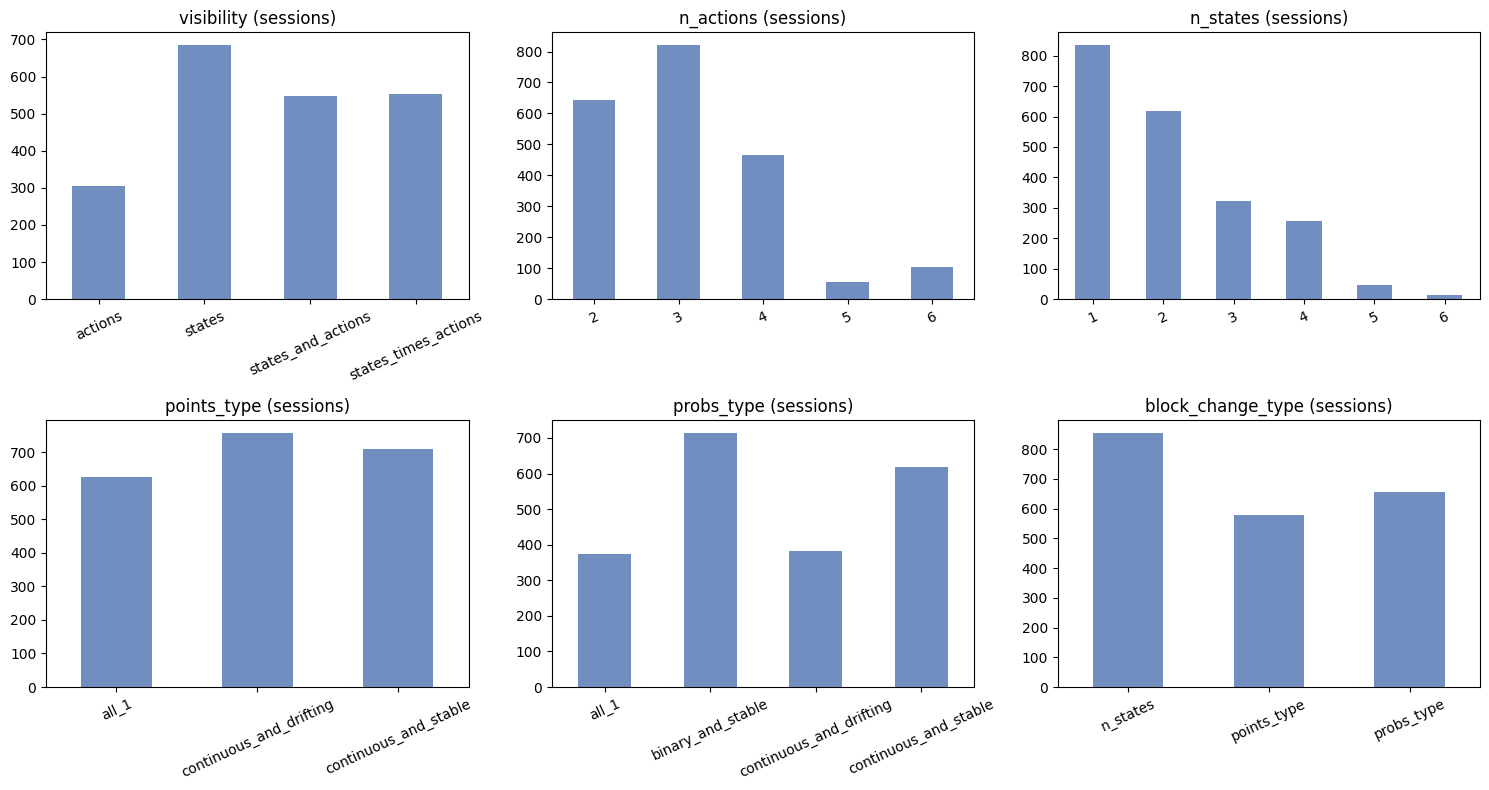

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feat in zip(axes.ravel(), ["visibility", "n_actions", "n_states", "points_type", "probs_type", "block_change_type"]):
    DM.df.groupby(feat).size().plot(kind="bar", ax=ax, color="#4C72B0", alpha=0.8)
    ax.set_title(f"{feat} (sessions)")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()


## 3. Design-Level Split: Hold Out Unseen `task_number`s

The Hack baseline used a **single task + session-level split** — test sessions share the same design as training sessions, so the model only re-runs on a different reward instantiation. Here we switch to a **design-level hold-out**:

- all sessions of a given `task_number` (design) land in exactly one split;
- the test set contains designs the model never saw during training, so this measures true **cross-task generalization**;
- 70/15/15 (train/val/test); the val split is used to watch GRU early stopping (it does not participate in fitting).

In [21]:
train_df, val_df, test_df, split_summary = utils.split_task_designs(
    DM, train_frac=CONFIG["train_frac"], val_frac=CONFIG["val_frac"], seed=CONFIG["seed"])
split_summary


,split,n_designs,n_sessions,n_trials
0,train,986,1238,246508
1,val,211,318,63371
2,test,212,534,106156


In [22]:
balance = utils.feature_balance_table(
    train_df, val_df, test_df,
    ["visibility", "n_actions", "n_states", "points_type", "probs_type"])
balance.pivot_table(index=["feature", "value"], columns="split", values="n_sessions", fill_value=0)


split                                 test  train    val
feature     value                                       
n_actions   2                        280.0  300.0   62.0
            3                        111.0  498.0  212.0
            4                         32.0  406.0   29.0
            5                         11.0   33.0   12.0
            6                        100.0    1.0    3.0
n_states    1                        274.0  513.0   48.0
            2                         72.0  371.0  175.0
            3                         49.0  207.0   65.0
            4                        128.0  106.0   22.0
            5                         10.0   30.0    5.0
            6                          1.0   11.0    3.0
points_type all_1                    255.0  222.0  148.0
            continuous_and_drifting  176.0  494.0   87.0
            continuous_and_stable    103.0  522.0   83.0
probs_type  all_1                     36.0  296.0   43.0
            binary_and_stable        167.0  387.0  160.0
            continuous_and_drifting   60.0  262.0   61.0
            continuous_and_stable    271.0  293.0   54.0
visibility  actions                  222.0   69.0   14.0
            states                    72.0  449.0  164.0
            states_and_actions       174.0  303.0   70.0
            states_times_actions      66.0  417.0   70.0

## 4. Model Fitting

**Rescorla-Wagner (baseline)**: a 2-parameter (α, β) Q-learner. We fit a single (α, β) on the pooled train sessions (`fit` now supports sessions with different `n_actions`, see `Model_RescorlaWagner.py`); every held-out session initializes Q0 with its own mean reward and updates trial by trial — i.e. a "replay" evaluation.

**Shared GRU**: one model trained on all designs. The input is the workshop's 73-dim vector `[a_{t-1}(6), choices_available(6), s_t(30), s_{t-1}(30), r_{t-1}/100(1)]`; the output is a fixed 6-arm space with an available-actions mask (so tasks with n_actions = 2..6 can be mixed). A single full batch over all sessions is slow, so we use minibatching (`batch_size`).

In [23]:
t0 = time.time()
rw_model, rw_used = utils.fit_rw_pooled(train_df, seed=CONFIG["seed"], max_sessions=CONFIG["max_rw_sessions"])
print(f"RW fitted on {len(rw_used)} train sessions in {time.time() - t0:.1f}s")
rw_model.get_model_description()


Fit successful! Alpha: 0.547, Beta: 0.039; NLL: 55342.310
RW fitted on 300 train sessions in 23.5s


{'name': 'RescorlaWagnerModel',
 'fitted_status': 'Fitted',
 'description': 'Standard Rescorla-Wagner model with Softmax choice.',
 'n_parameters': 2,
 'latent_shape': (197, 3),
 'parameters': 'Alpha: 0.547, Beta: 0.039'}

GRU fit complete. Mean NLL/trial: 0.8037
GRU trained on 1238 train sessions in 19.6s


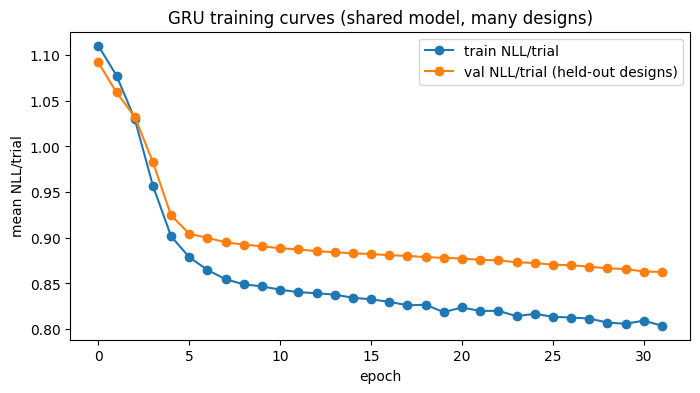

In [24]:
t0 = time.time()
gru_model, gru_used = utils.train_gru(
    train_df, val_df,
    hidden_size=CONFIG["hidden_size"],
    learning_rate=CONFIG["learning_rate"],
    n_epochs=CONFIG["n_epochs"],
    batch_size=CONFIG["batch_size"],
    seed=CONFIG["seed"],
    max_sessions=CONFIG["max_gru_sessions"],
)
print(f"GRU trained on {len(gru_used)} train sessions in {time.time() - t0:.1f}s")

plt.figure(figsize=(8, 4))
plt.plot(gru_model.loss_history, "-o", label="train NLL/trial")
plt.plot(gru_model.test_loss_history, "-o", label="val NLL/trial (held-out designs)")
plt.xlabel("epoch")
plt.ylabel("mean NLL/trial")
plt.title("GRU training curves (shared model, many designs)")
plt.legend()
plt.show()


## 5. Held-Out Evaluation: Generalization + Comparison with Human Behavior

**Replay semantics** (same as Hack): weights are frozen; the real history of a held-out session is fed trial by trial (`a_{t-1}, s_t, s_{t-1}, r_{t-1}` are all observed values) and the model outputs `P(a_t | history)`. Held-out rewards/choices only enter the forward pass, never the gradient. Because every session starts from `h₀ = 0`, the model has to **adapt on the fly** to the reward structure of the new design — the best-action curve is a learning curve that rises from near chance and measures the "adaptation speed".

Metrics:
- **NLL/trial** and **pseudo-R²** (relative to random guessing) — overall predictive quality;
- **best-action curve** — humans: whether the optimal arm was chosen on each trial; models: the probability assigned to the optimal arm.

In [25]:
test_rows = [row for _, row in test_df.iterrows()]

# One forward pass per model over the test sessions; gives per-session metrics
rw_detail = utils.session_metrics(rw_model, test_rows)
gru_detail = utils.session_metrics(gru_model, test_rows)

eval_records = [
    {"model": "Rescorla-Wagner", **utils.summarize_sessions(rw_detail)},
    {"model": "GRU", **utils.summarize_sessions(gru_detail)},
]
eval_df = pd.DataFrame(eval_records).round(4)
eval_df

,model,NLL,n_trials,NLL_per_trial,Pseudo_R2
0,Rescorla-Wagner,90075.3766,106156,0.8485,0.1860
1,GRU,82006.8344,106156,0.7725,0.2589


In [26]:
def evaluate_by_feature(detail, feature):
    records = []
    for value, grp in detail.groupby(feature):
        if len(grp) < 3:
            continue
        m = utils.summarize_sessions(grp)
        records.append({"feature": feature, "value": value, **m})
    return pd.DataFrame(records)

by_feature = []
for name, detail in [("RW", rw_detail), ("GRU", gru_detail)]:
    for feat in ["visibility", "n_actions", "points_type", "probs_type", "block_change_type"]:
        part = evaluate_by_feature(detail, feat)
        part.insert(0, "model", name)
        by_feature.append(part)
by_feature_df = pd.concat(by_feature, ignore_index=True)
by_feature_df[["NLL_per_trial", "Pseudo_R2"]] = by_feature_df[["NLL_per_trial", "Pseudo_R2"]].round(4)
by_feature_df.pivot_table(index=["feature", "value"], columns="model", values="NLL_per_trial")

model                                         GRU      RW
feature           value                                  
block_change_type n_states                 0.6932  0.8443
                  points_type              0.9523  0.9706
                  probs_type               0.7315  0.7877
n_actions         2                        0.5846  0.6697
                  3                        0.7844  0.9224
                  4                        0.9497  1.1685
                  5                        1.2629  1.3070
                  6                        1.1797  1.1184
points_type       all_1                    0.6125  0.7179
                  continuous_and_drifting  1.0047  1.0169
                  continuous_and_stable    0.7724  0.8847
probs_type        all_1                    0.6540  0.8380
                  binary_and_stable        0.9845  1.0251
                  continuous_and_drifting  0.8356  0.9120
                  continuous_and_stable    0.6434  0.7268
visibility        actions                  0.8412  0.8299
                  states                   0.7594  0.9109
                  states_and_actions       0.7041  0.8301
                  states_times_actions     0.7360  0.8918

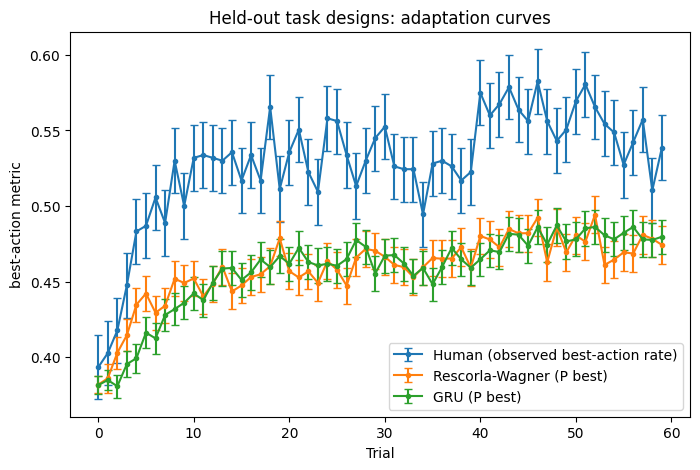

In [27]:
rw_probs = utils.replay_probs(rw_model, test_rows)
gru_probs = utils.replay_probs(gru_model, test_rows)

human_curves = [utils.best_action_curve_from_observed_actions(row, CONFIG["max_trials"]) for row in test_rows]
rw_curves = [utils.best_action_prob_curve_from_probs(p, row, CONFIG["max_trials"]) for p, row in zip(rw_probs, test_rows)]
gru_curves = [utils.best_action_prob_curve_from_probs(p, row, CONFIG["max_trials"]) for p, row in zip(gru_probs, test_rows)]

curves = {
    "Human (observed best-action rate)": utils.pull_average_learning_curve(human_curves, CONFIG["max_trials"]),
    "Rescorla-Wagner (P best)": utils.pull_average_learning_curve(rw_curves, CONFIG["max_trials"]),
    "GRU (P best)": utils.pull_average_learning_curve(gru_curves, CONFIG["max_trials"]),
}
utils.plot_learning_curves(
    curves,
    title="Held-out task designs: adaptation curves",
    ylabel="best-action metric",
    max_trials=CONFIG["max_trials"],
)
plt.show()

#### Best-action curves: GRU and RW compared separately by feature

The two figures below correspond to **GRU** and **RW**, respectively. Each subplot is one feature (`visibility` / `n_actions` / `points_type` / `probs_type` / `block_change_type`), and within a subplot curves are separated only by the **values of that feature** (different shades of the same color family), to compare how the model's learning curves differ across task conditions. The overall human-vs-model comparison is in the figure above.

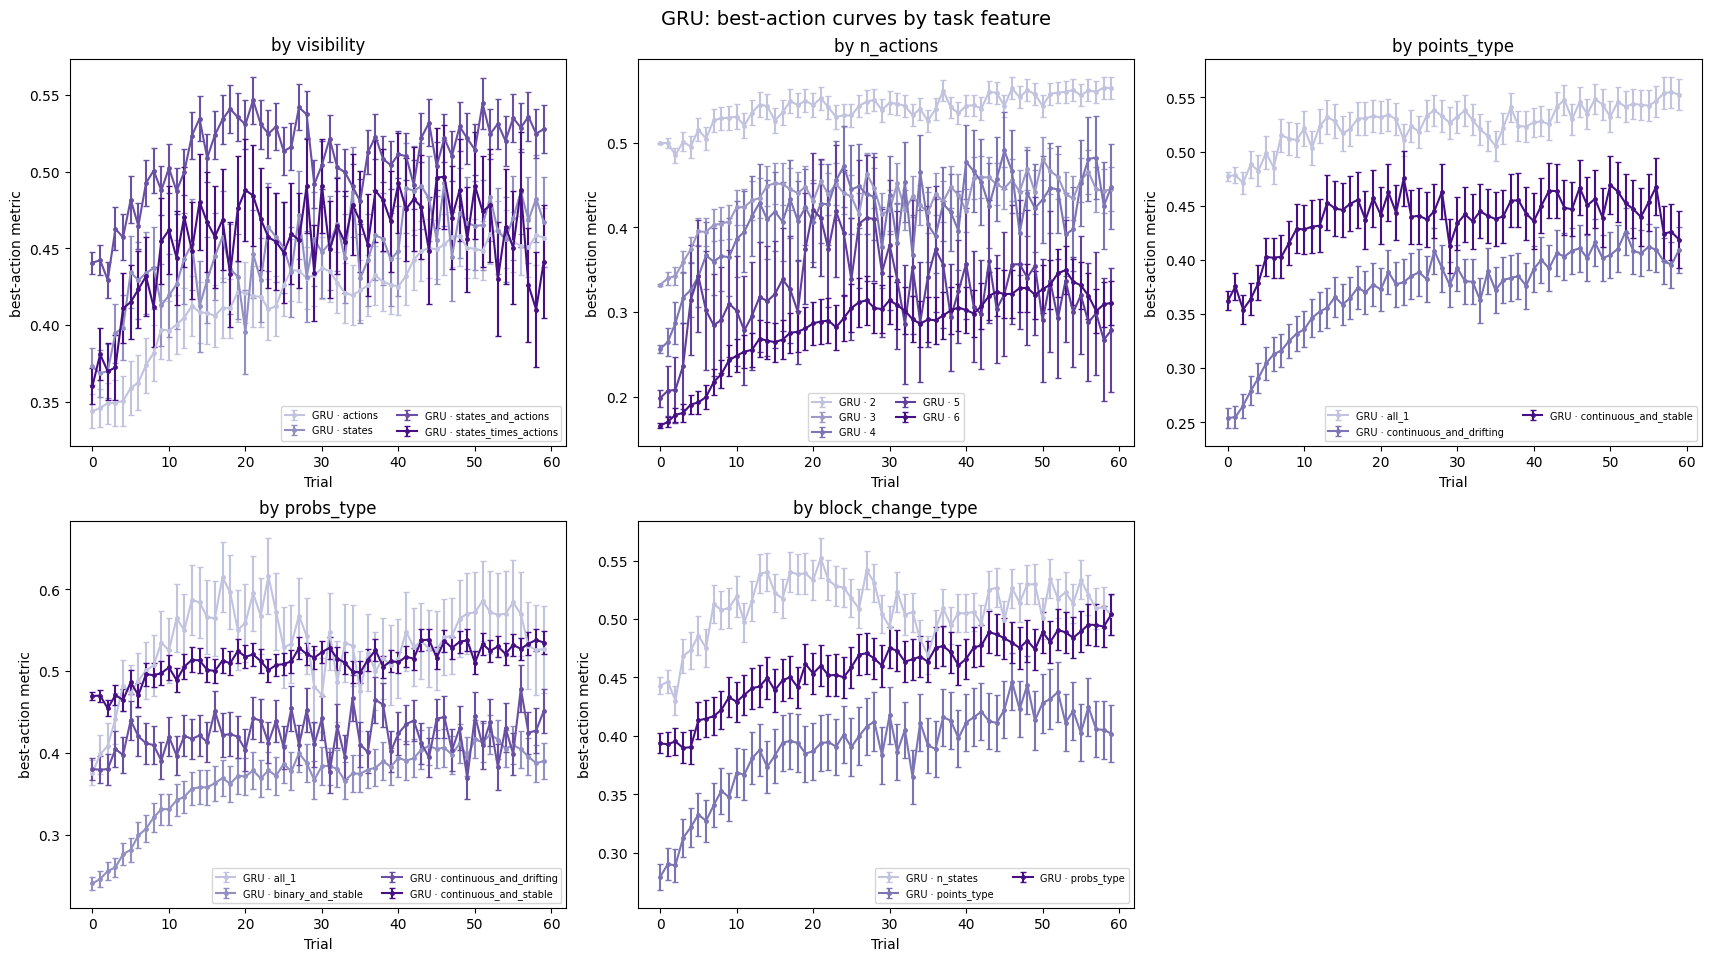

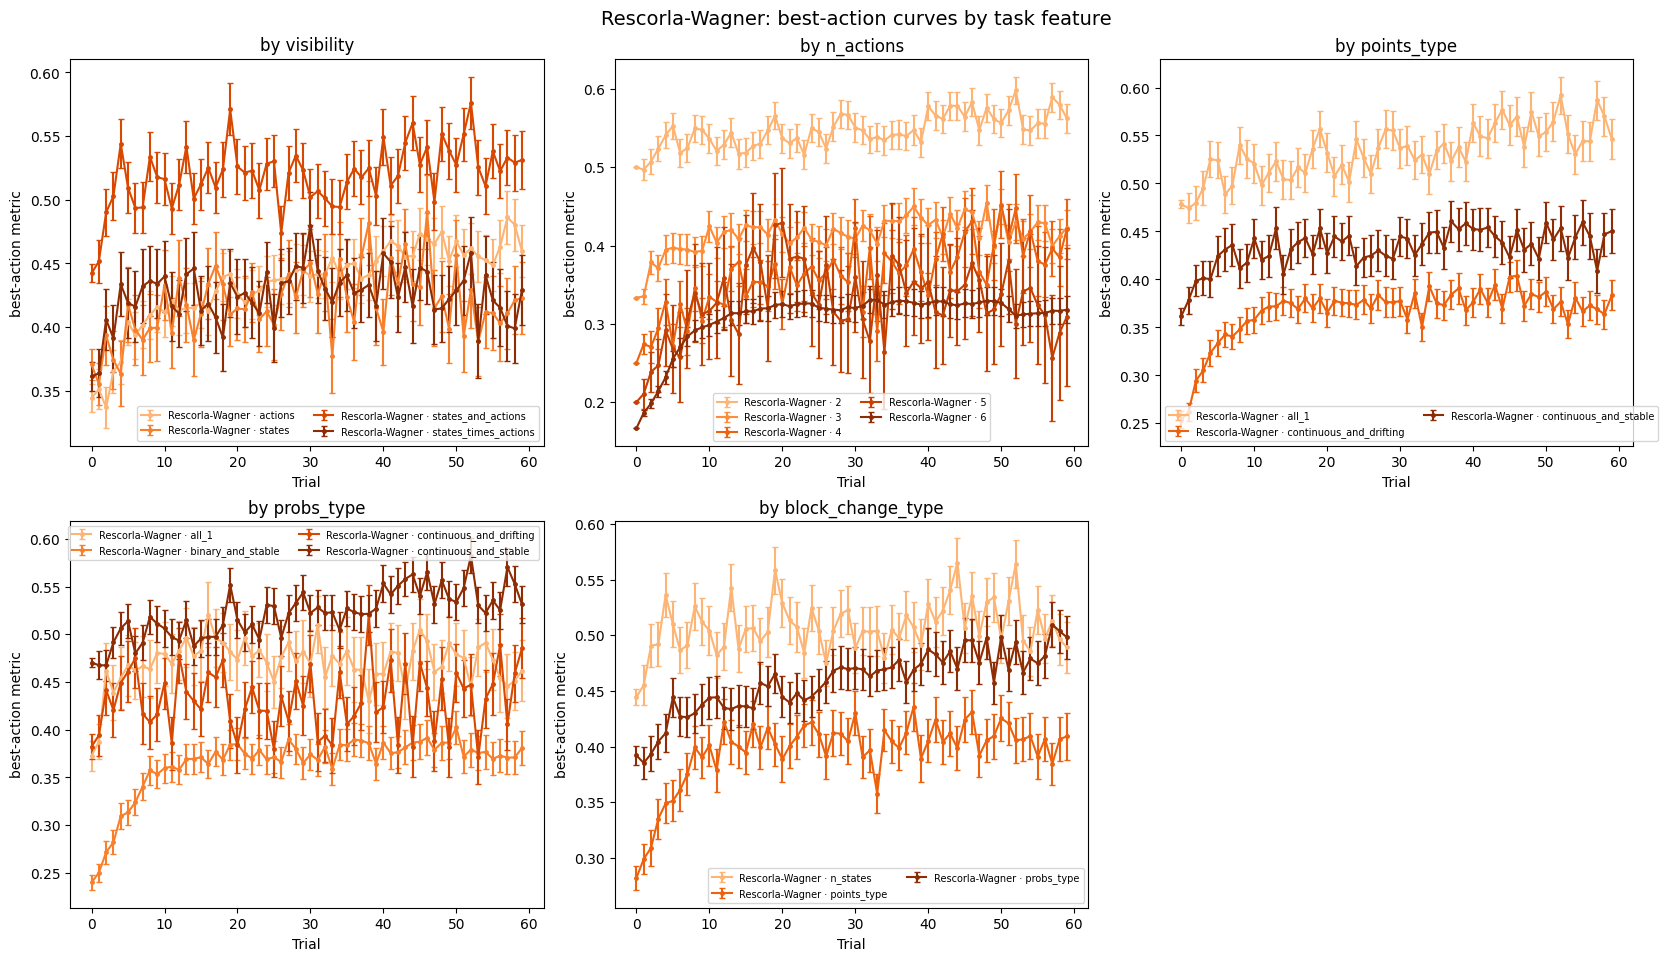

In [28]:
# Two figures, one for GRU and one for RW; each subplot is one feature, and
# curves within a subplot are separated by that feature's values (shades of the
# same color family) to compare the model's own learning curves across conditions.
features = ["visibility", "n_actions", "points_type", "probs_type", "block_change_type"]

def curves_by_feature_for(curves_list):
    """{feature: {value: (mean, se)}} for one model, from per-session curves."""
    out = {}
    for feat in features:
        by_value = {}
        for value, grp in test_df.groupby(feat):
            if len(grp) < 5:
                continue
            idx = grp.index.values  # *_curves are aligned with test_df row order
            by_value[value] = utils.pull_average_learning_curve(
                [curves_list[i] for i in idx], CONFIG["max_trials"])
        out[feat] = by_value
    return out

gru_by_feature = curves_by_feature_for(gru_curves)
rw_by_feature = curves_by_feature_for(rw_curves)

for model, cmap_name, by_feature in [
    ("GRU", "Purples", gru_by_feature),
    ("Rescorla-Wagner", "Oranges", rw_by_feature),
]:
    fig, axes = plt.subplots(2, 3, figsize=(17, 9.5), constrained_layout=True)
    for ax, feat in zip(axes.ravel(), features):
        utils.plot_model_curves_by_feature(
            {model: by_feature[feat]}, feat,
            max_trials=CONFIG["max_trials"], ax=ax, cmaps={model: cmap_name})
    for ax in axes.ravel()[len(features):]:
        ax.axis("off")
    fig.suptitle(f"{model}: best-action curves by task feature", fontsize=14)
    plt.show()

## 6. Dynamics Analysis: Hidden States and Gates

The analysis object is the same **fixed-weight shared model** (not a separately trained "full model"): we replay it on held-out sessions and collect, trial by trial:

- hidden state `h_t` (32-dim) — the GRU's internal belief before the decision on trial t;
- update gate `z_t` (write rate) and reset gate `r_t` (forget/reset) — the mechanistic counterpart of a "parameterized α";
- task metadata for every trial, to group by condition.

Then: PCA to see whether the latent space separates by task features; gate curves to compare write/reset strategies across conditions; linear probes to see how much task/behavioral information can be decoded from `h_t`.

In [29]:
latent_df = utils.collect_latents(gru_model, test_rows)
print("trials x columns:", latent_df.shape)
latent_df[["task_id", "trial", "state", "action", "reward", "best_chosen", "stay",
           "visibility", "n_actions"]].head()


trials x columns: (106156, 115)


,task_id,trial,state,action,reward,best_chosen,stay,visibility,n_actions
0,task_620,0,0,2,58.0,True,False,states_times_actions,4
1,task_620,1,1,1,0.0,True,False,states_times_actions,4
2,task_620,2,1,3,0.0,False,False,states_times_actions,4
3,task_620,3,0,0,0.0,False,False,states_times_actions,4
4,task_620,4,0,2,58.0,True,False,states_times_actions,4


explained variance ratio (PC1, PC2): [0.43 0.22]


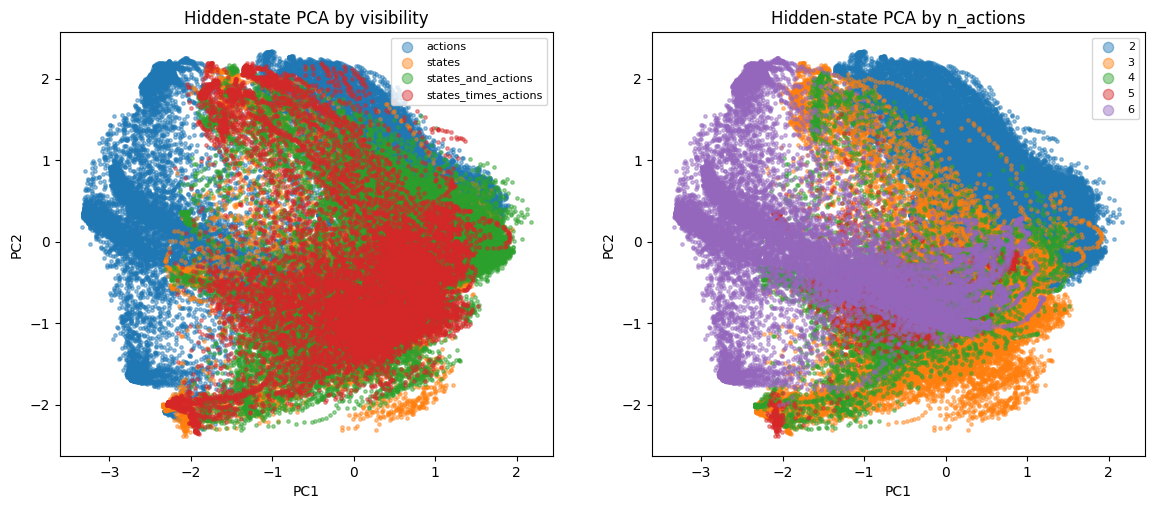

In [30]:
Xh = latent_df[utils.hidden_columns(latent_df)].values
pca = utils.pca_scores(Xh, n_components=2)
latent_df["PC1"], latent_df["PC2"] = pca["scores"][:, 0], pca["scores"][:, 1]
print("explained variance ratio (PC1, PC2):", pca["explained_var_ratio"].round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
utils.plot_pca_by_feature(latent_df, "visibility", ax=axes[0])
utils.plot_pca_by_feature(latent_df, "n_actions", ax=axes[1])
plt.show()


#### Non-linear embedding: t-SNE of the hidden states

PCA is a linear projection, so it can miss non-linear structure in the latent
space. The two panels below run **t-SNE** on a
balanced subsample of hidden states (up to `n_per_group` trials per
`visibility` value), to check whether the latent space clusters by task
condition. If colors separate, the GRU's hidden state encodes the condition; if
they overlap, the dynamics are largely shared across conditions.

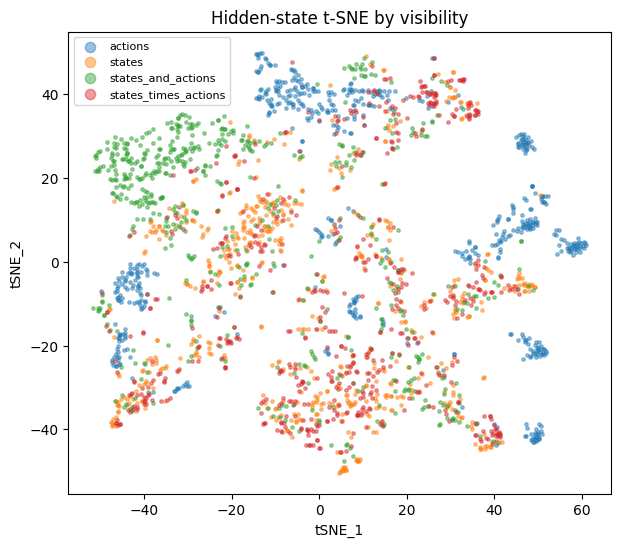

In [37]:
# Non-linear embedding of the hidden states, balanced across visibility values.
embed_cfg = {"n_per_group": 600, "seed": CONFIG["seed"]}

sub = utils.balanced_subset(latent_df, by="visibility",
                            n_per_group=embed_cfg["n_per_group"], seed=embed_cfg["seed"])
Xsub = sub[utils.hidden_columns(latent_df)].values


embeddings_tsne = utils.embed_2d(Xsub, method="tsne", seed=embed_cfg["seed"])

sub = sub.copy()
sub[f"tSNE_1"], sub[f"tSNE_2"] = embeddings_tsne[:, 0], embeddings_tsne[:, 1]

embeddings = {
    "UMAP": utils.embed_2d(Xsub, method="umap", seed=embed_cfg["seed"]),
    "t-SNE": utils.embed_2d(Xsub, method="tsne", seed=embed_cfg["seed"]),
}
# for name, emb in embeddings.items():
#     sub[f"{name}_1"], sub[f"{name}_2"] = emb[:, 0], emb[:, 1]

# fig, axes = plt.subplots(1, 2, figsize=(14, 6))
# for ax, name in zip(axes, embeddings):
utils.plot_scatter_by_feature(sub, f"tSNE_1", f"tSNE_2", "visibility", title=f"Hidden-state {name} by visibility")
plt.show()

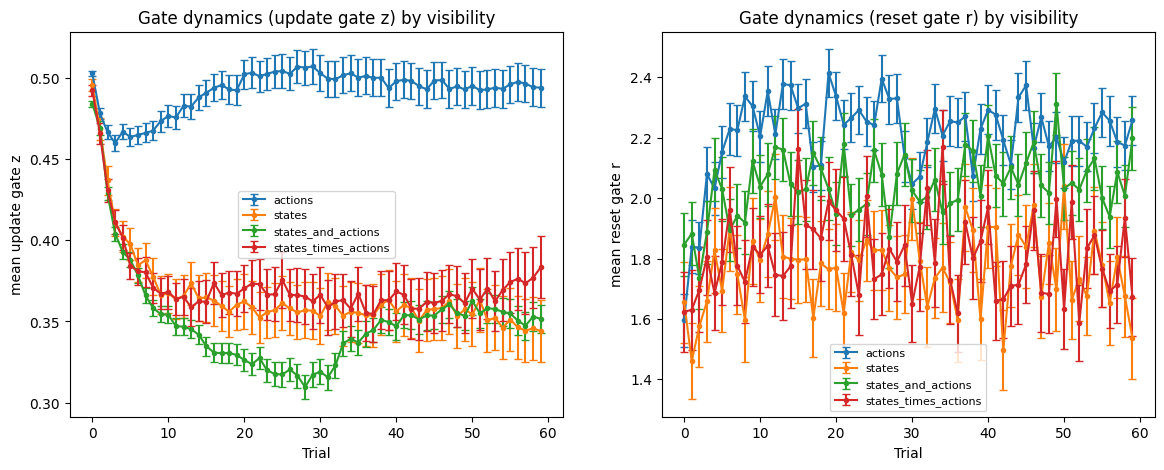

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
utils.plot_gate_curves(latent_df, gate="update", feature="visibility",
                       max_trials=CONFIG["max_trials"], ax=axes[0])
utils.plot_gate_curves(latent_df, gate="reset", feature="visibility",
                       max_trials=CONFIG["max_trials"], ax=axes[1])
plt.show()


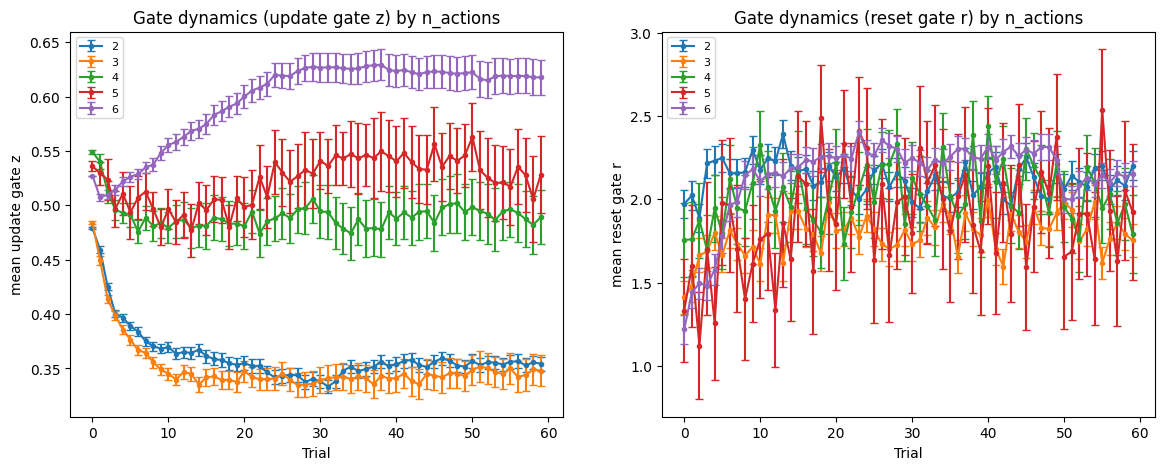

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
utils.plot_gate_curves(latent_df, gate="update", feature="n_actions",
                       max_trials=CONFIG["max_trials"], ax=axes[0])
utils.plot_gate_curves(latent_df, gate="reset", feature="n_actions",
                       max_trials=CONFIG["max_trials"], ax=axes[1])
plt.show()


In [33]:
probe_results = []
for feat in ["visibility", "n_actions", "n_states", "points_type", "probs_type",
             "block_change_type", "points_relationship", "block_change_level"]:
    probe_results.append(utils.run_feature_probe(
        latent_df, feat, CONFIG["hidden_size"], seed=CONFIG["seed"],
        max_sessions=CONFIG["max_probe_sessions"]))
probe_results.append(utils.run_action_probe(
    latent_df, CONFIG["hidden_size"], seed=CONFIG["seed"],
    max_sessions=CONFIG["max_probe_sessions"]))
probe_results.append(utils.run_binary_probe(
    latent_df, "stay", CONFIG["hidden_size"], seed=CONFIG["seed"],
    max_sessions=CONFIG["max_probe_sessions"]))
probe_results.append(utils.run_binary_probe(
    latent_df, "best_chosen", CONFIG["hidden_size"], seed=CONFIG["seed"],
    max_sessions=CONFIG["max_probe_sessions"]))

def probe_chance(r):
    if r["feature"] == "next_action":
        return float((1.0 / latent_df["n_actions"]).mean())
    return 1.0 / r["n_classes"]

probe_tbl = pd.DataFrame([{
    "probe": r["feature"],
    "train_acc": round(r["train_acc"], 3),
    "val_acc": round(r["val_acc"], 3),
    "chance": round(probe_chance(r), 3),
    "n_train_trials": r["n_train_trials"],
    "n_val_trials": r["n_val_trials"],
} for r in probe_results])
probe_tbl


,probe,train_acc,val_acc,chance,n_train_trials,n_val_trials
0,visibility,0.880,0.684,0.250,12773,3191
1,n_actions,1.000,0.998,0.200,12773,3191
2,n_states,0.933,0.843,0.200,12773,3191
3,points_type,0.816,0.789,0.333,12773,3191
4,probs_type,0.828,0.620,0.250,12773,3191
5,block_change_type,0.810,0.794,0.333,12773,3191
6,points_relationship,0.823,0.735,0.333,12773,3191
7,block_change_level,0.842,0.830,0.500,12773,3191
8,next_action,0.679,0.613,0.382,12773,3191
9,stay,0.690,0.637,0.500,12773,3191


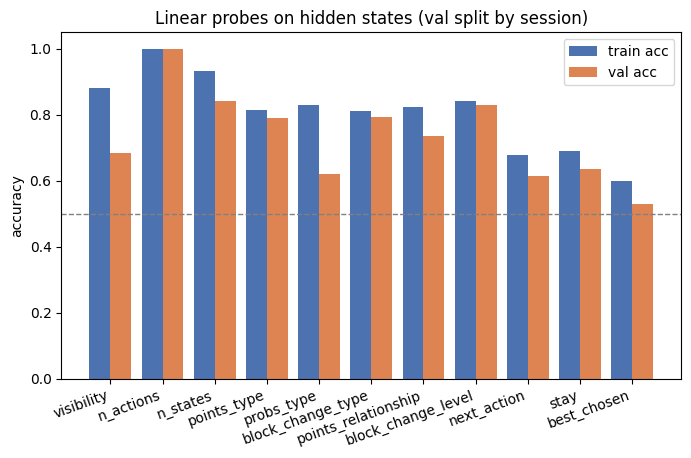

In [34]:
utils.plot_probe_results(probe_results)
plt.show()


## 7. Summary & Next Steps

**What this notebook does**

- Design-level 70/15/15 split by `task_number`; the test set contains designs the model never saw;
- Trains one shared GRU (73-dim workshop input, 6-arm masked softmax, minibatching) and fits a cross-task pooled RW baseline;
- Reports NLL/trial, pseudo-R², and best-action adaptation curves on held-out designs (overall + grouped by task feature), alongside human curves;
- Collects hidden/gates and runs PCA and linear probes.

**How to continue**

1. **Scale up**: raise `max_gru_sessions` / `n_epochs` / `max_rw_sessions` in `CONFIG` (or set to `None`) to use all 1400+ designs.
2. **Stronger generalization metrics**: replace the best-action curves with "trials to reach chance+50%" or per-condition pseudo-R² tables; train separate models per task condition and compare their inductive biases.
3. **Deeper mechanism analysis**: temporally aligned CCA/Procrustes on `h_t`; correlate `z_t / r_t` with per-session RW α; add state or prediction-error targets to the probes.
4. **Model-side TODO**: `Model_RNN.py` still uses the old interface (no state input); once aligned it can be compared with the GRU on the same footing; visibility could also be added as an input feature.

**Caveats**

- RW initializes Q0 with the held-out session's own mean reward (same shortcut as the Hack baseline);
- in the `actions` condition the state is always 0 (n_states=1), so the GRU's `s_t` carries no information there; for `states_times_actions` the state is implicit in the displayed images, and the model getting the index directly is information-equivalent but privileged;
- probe validation is split by session to avoid same-session leakage, but interpret per-condition results carefully when sample sizes are unbalanced.